# **California Housing Prices Prediction**

##   **Importing Dependencies**

In [1]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform, bootstrap
from pandas.plotting import scatter_matrix

from pathlib import Path
import tarfile
import urllib.request
from io import BytesIO
import joblib

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import make_column_transformer, make_column_selector, ColumnTransformer

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, mean_squared_error

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

##   **Data Collection & Exploration**

In [5]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
        
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_data = load_housing_data()

In [6]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
housing_data.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [8]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [10]:
housing_data.shape

(20640, 10)

In [11]:
housing_data.sample(n=10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
17298,-122.51,37.76,40.0,2320.0,562.0,1499.0,521.0,3.2792,260800.0,NEAR OCEAN
11646,-121.12,37.73,35.0,1107.0,227.0,573.0,210.0,2.3924,102200.0,INLAND
6406,-122.24,37.82,52.0,3665.0,517.0,1470.0,520.0,6.1550,398600.0,NEAR BAY
20359,-121.97,37.79,17.0,5688.0,824.0,2111.0,773.0,6.6131,312500.0,<1H OCEAN
15256,-118.45,34.12,20.0,10722.0,1617.0,3731.0,1511.0,9.7449,500001.0,<1H OCEAN
14712,-117.00,32.71,22.0,2263.0,441.0,1395.0,416.0,3.7250,123500.0,NEAR OCEAN
2449,-117.29,33.19,18.0,6235.0,1233.0,4127.0,1162.0,3.0704,151600.0,NEAR OCEAN
6484,-118.14,34.18,52.0,1700.0,317.0,996.0,329.0,3.9688,175000.0,<1H OCEAN
16921,-117.94,33.70,18.0,4827.0,718.0,2471.0,716.0,6.1181,284500.0,<1H OCEAN
19824,-122.66,38.81,22.0,852.0,176.0,461.0,142.0,3.4375,83300.0,INLAND


In [12]:
housing_data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

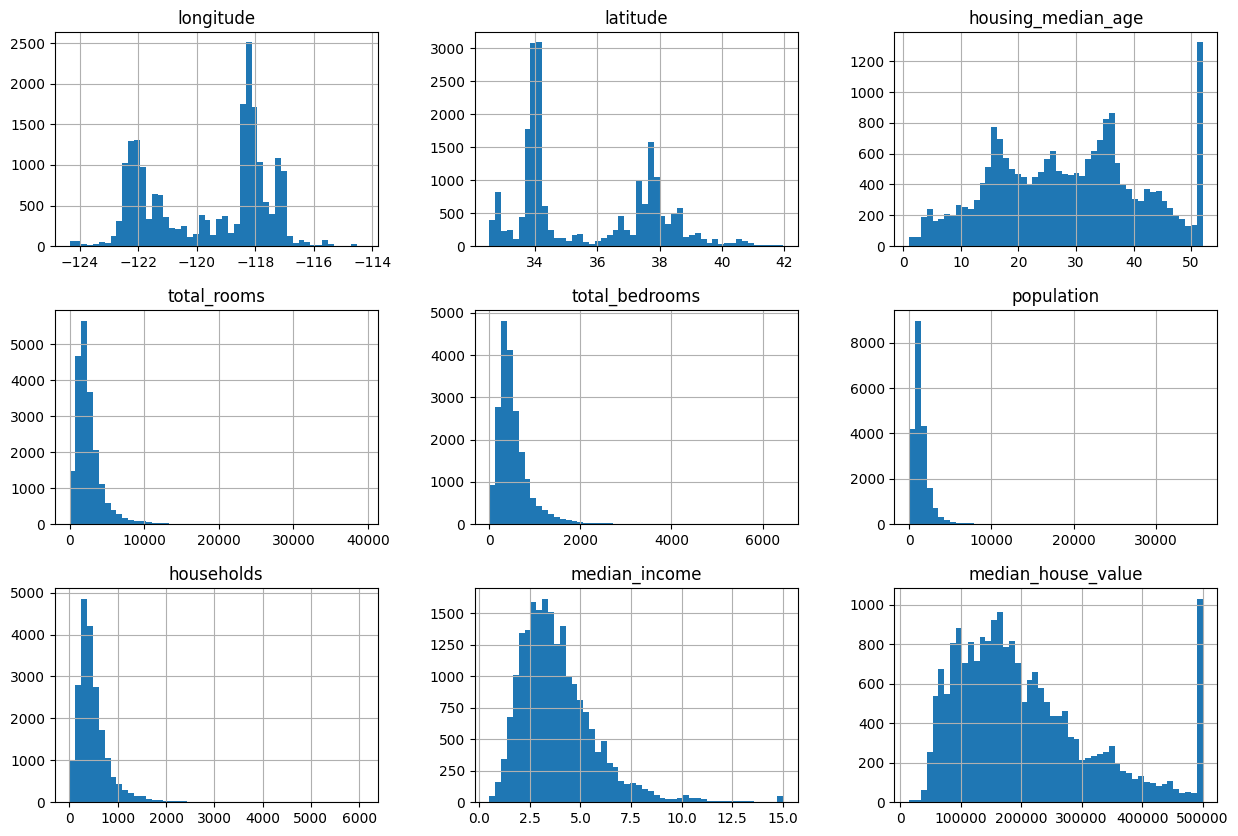

In [13]:
housing_data.hist(bins=50, figsize=(15,10))
plt.show()

In [14]:
housing_data["income_cat"] = pd.cut(housing_data["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1,2,3,4,5])

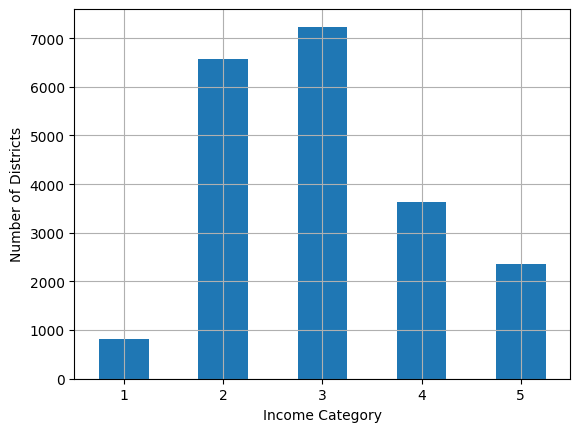

In [15]:
housing_data["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income Category")
plt.ylabel("Number of Districts")
plt.show()

##   **Data Splitting**

In [16]:
train_set, test_set = train_test_split(housing_data, test_size=0.2, stratify=housing_data["income_cat"], random_state=3)

In [17]:
test_set["income_cat"].value_counts()/len(test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [18]:
train_set["income_cat"].value_counts()/len(train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [19]:
for set_ in (train_set, test_set):
    set_.drop("income_cat", axis=1, inplace=True)

##   **Exploratory Data Analysis (EDA)**

In [20]:
housing = train_set.copy()

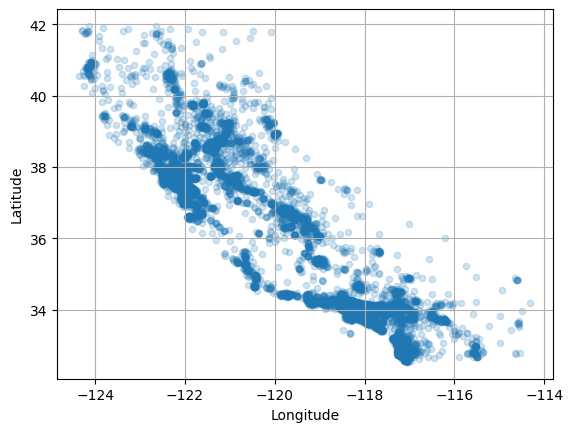

In [21]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

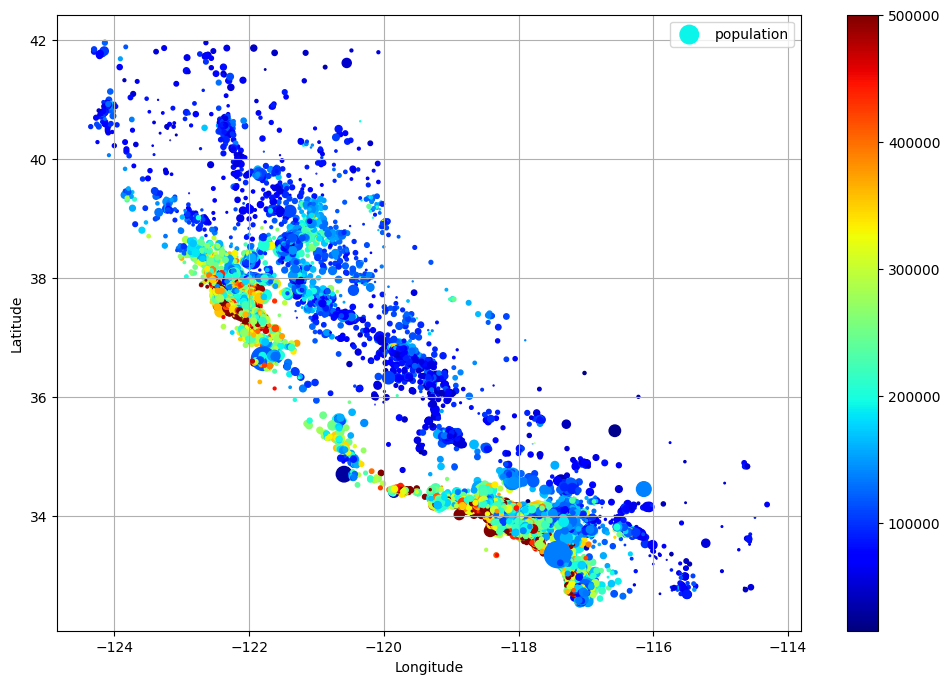

In [22]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, 
             s=housing["population"]/100, label="population", 
             c=housing["median_house_value"], cmap="jet", 
             colorbar=True, legend=True, sharex=False, figsize=(12,8))
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

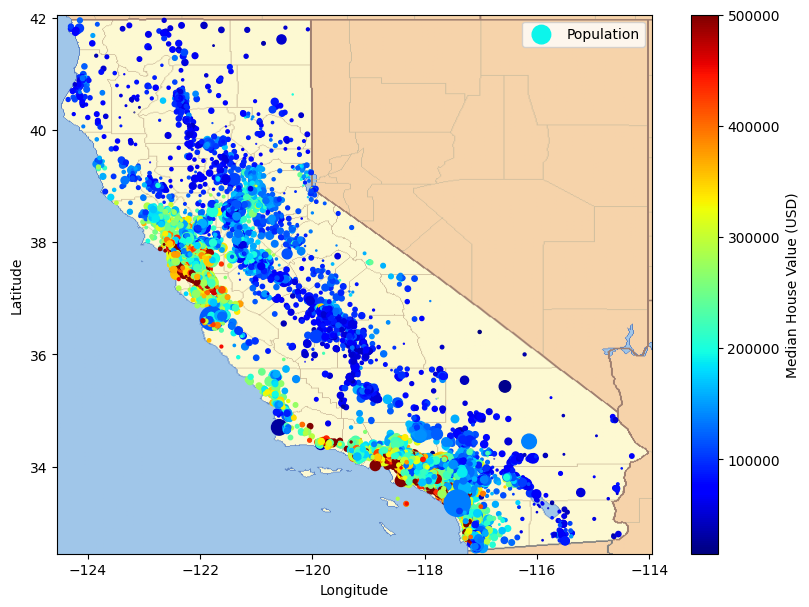

In [23]:
url = "https://github.com/ageron/handson-ml3/raw/main/images/end_to_end_project/california.png"
with urllib.request.urlopen(url) as response:
    california_img = plt.imread(BytesIO(response.read()))

housing_renamed = housing.rename(columns={"latitude": "Latitude", "longitude": "Longitude", "population": "Population", 
                                          "median_house_value": "Median House Value (USD)"})

housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", 
                     s=housing_renamed["Population"] / 100, label="Population", 
                     c="Median House Value (USD)", cmap="jet", colorbar=True, legend=True, sharex=False, figsize=(10, 7))

axis = [-124.55, -113.95, 32.45, 42.05]
plt.axis(axis)
plt.imshow(california_img, extent=axis)
plt.show()

### **Exploring Correlations**

In [24]:
corr_matrix = housing.corr(numeric_only=True)

In [25]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687778
total_rooms           0.132725
housing_median_age    0.104174
households            0.066143
total_bedrooms        0.048847
population           -0.025532
longitude            -0.047638
latitude             -0.141908
Name: median_house_value, dtype: float64

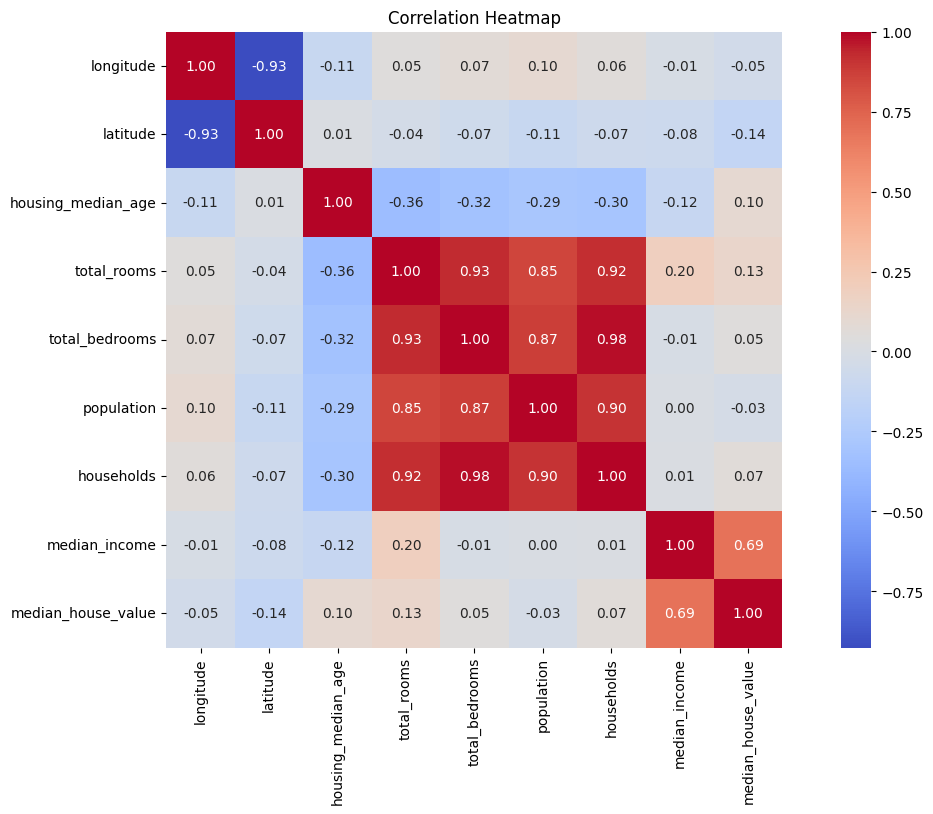

In [26]:
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix, cbar=True, square=True, fmt='.2f', annot=True, annot_kws={'size':10}, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

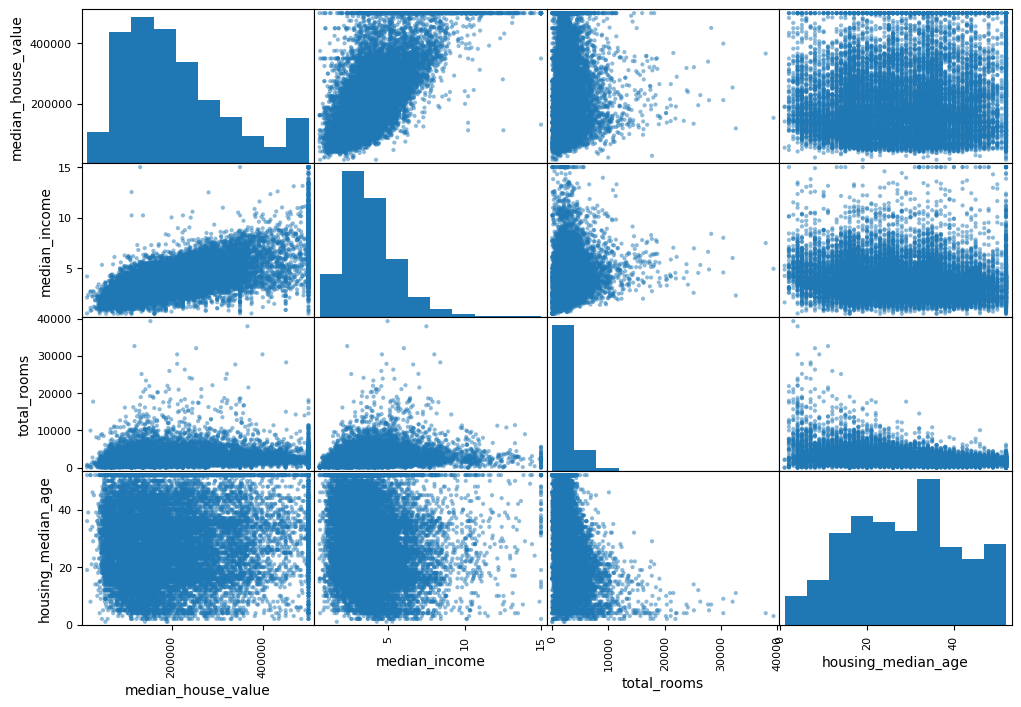

In [27]:
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12,8))
plt.show()

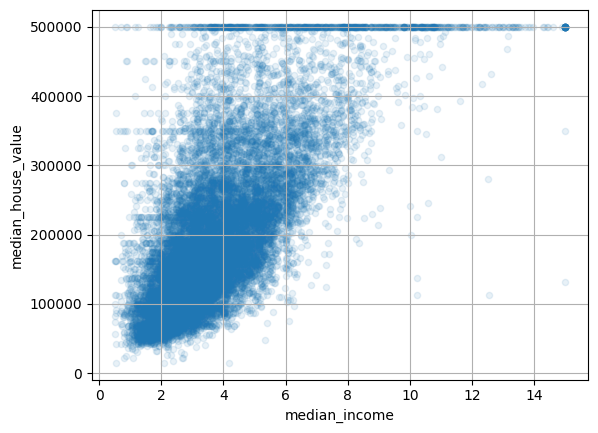

In [28]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)
plt.show()

In [29]:
housing["rooms_per_house"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["people_per_house"] = housing["population"]/housing["households"]

In [30]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687778
rooms_per_house       0.147878
total_rooms           0.132725
housing_median_age    0.104174
households            0.066143
total_bedrooms        0.048847
people_per_house     -0.019811
population           -0.025532
longitude            -0.047638
latitude             -0.141908
bedrooms_ratio       -0.255438
Name: median_house_value, dtype: float64

##   **Data Preprocessing**

###   **Features and Labels Splitting**

In [31]:
housing = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"].copy()

###   **Handling Numerical Attributes**

In [32]:
imputer = SimpleImputer(strategy="median")

In [33]:
housing_num = housing.select_dtypes(include=[np.number])

In [34]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [35]:
imputer.statistics_

array([-118.49  ,   34.25  ,   29.    , 2130.    ,  435.    , 1165.    ,
        409.    ,    3.5313])

In [36]:
housing_num.median().values

array([-118.49  ,   34.25  ,   29.    , 2130.    ,  435.    , 1165.    ,
        409.    ,    3.5313])

In [37]:
X = imputer.transform(housing_num)

In [38]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

###   **Handling Text and Categorical Attributes**

In [39]:
housing_cat = housing[["ocean_proximity"]]

In [40]:
cat_encoder = OneHotEncoder()
housing_cat_encoded = cat_encoder.fit_transform(housing_cat)

In [41]:
housing_cat_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

## **Feature Scaling and Transformation**  

In [42]:
scaler = StandardScaler()
housing_num_scaled = scaler.fit_transform(housing_num)

In [43]:
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

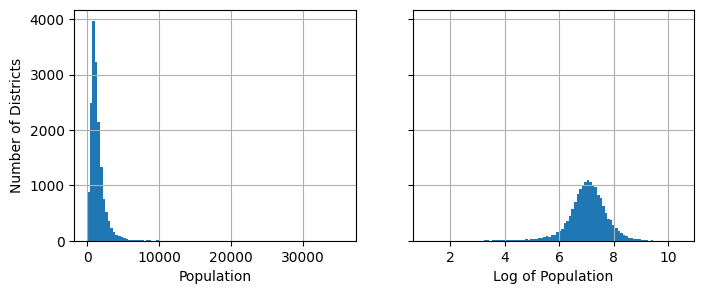

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axes[0], bins=100)
housing["population"].apply(np.log).hist(ax=axes[1], bins=100)
axes[0].set_xlabel("Population")
axes[1].set_xlabel("Log of Population")
axes[0].set_ylabel("Number of Districts")
plt.show()

In [45]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmean_ = KMeans(self.n_clusters, n_init = 10, random_state=self.random_state)
        self.kmean_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmean_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} Similarity" for i in range(self.n_clusters)]

In [46]:
cluster_similarity = ClusterSimilarity(n_clusters=10, gamma=1., random_state=3)
similarities = cluster_similarity.fit_transform(housing[["latitude", "longitude"]])

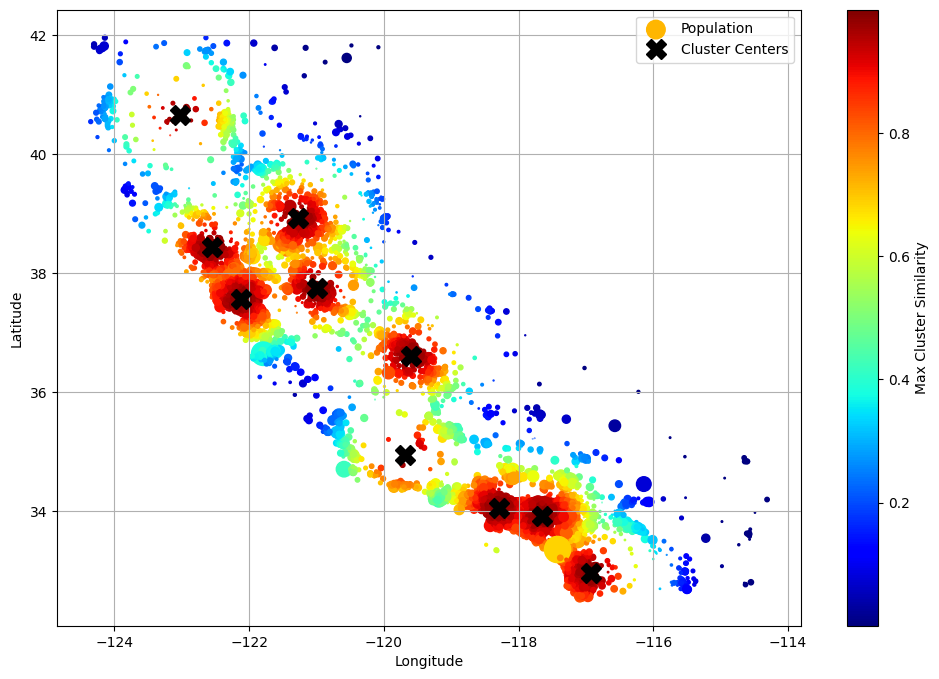

In [47]:
housing_renamed = housing.rename(columns={"latitude": "Latitude", "longitude": "Longitude", "population": "Population", 
                                          "median_house_value": "Median House Value (USD)"})

housing_renamed["Max Cluster Similarity"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                    s=housing_renamed["Population"]/100, label="Population", c="Max Cluster Similarity", 
                    cmap="jet", colorbar=True, legend=True, sharex=False, figsize=(12,8))

plt.plot(cluster_similarity.kmean_.cluster_centers_[:, 1], cluster_similarity.kmean_.cluster_centers_[:, 0], 
         linestyle="", color="black", marker="X", markersize=14, label="Cluster Centers")

plt.legend(loc="upper right")
plt.show()

In [48]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)

In [49]:
housing_prepared = preprocessing.fit_transform(train_set)

## **Preprocessing & Feature Engineering Pipeline** 

In [50]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmean_ = KMeans(self.n_clusters, n_init = 10, random_state=self.random_state)
        self.kmean_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmean_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} Similarity" for i in range(self.n_clusters)]

In [51]:
def column_ratio(X):
    return X[:, [0]]/X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

cluster_similarity = ClusterSimilarity(n_clusters=10, gamma=1., random_state=3)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", cluster_similarity, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object))
],
    remainder=default_num_pipeline
)

In [52]:
housing_processed = preprocessing.fit_transform(housing)

In [53]:
housing_processed.shape

(16512, 24)

In [54]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 Similarity',
       'geo__Cluster 1 Similarity', 'geo__Cluster 2 Similarity',
       'geo__Cluster 3 Similarity', 'geo__Cluster 4 Similarity',
       'geo__Cluster 5 Similarity', 'geo__Cluster 6 Similarity',
       'geo__Cluster 7 Similarity', 'geo__Cluster 8 Similarity',
       'geo__Cluster 9 Similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

## **Model Training & Evaluation** 

### **Linear Regression** 

In [55]:
linear_reg = make_pipeline(preprocessing, LinearRegression())

In [56]:
linear_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7e3...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=3),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e308b3e4080>)])),
                ('linearregression', LinearRegression())])

In [57]:
linear_reg_pred = linear_reg.predict(housing)

In [58]:
linear_reg_rmse = root_mean_squared_error(housing_labels, linear_reg_pred)
linear_reg_mae = mean_absolute_error(housing_labels, linear_reg_pred)
linear_reg_r2 = r2_score(housing_labels, linear_reg_pred)
linear_reg_mse = mean_squared_error(housing_labels, linear_reg_pred)
print(f"Root Mean Squared Error (RMSE): ",linear_reg_rmse)
print(f"Mean Absolute Error (MAE): ",linear_reg_mae)
print(f"R2 Score: ",linear_reg_r2)
print(f"Mean Squared Error (MSE): ",linear_reg_mse)

Root Mean Squared Error (RMSE):  69381.52352735904
Mean Absolute Error (MAE):  51223.87777798917
R2 Score:  0.6391080032584999
Mean Squared Error (MSE):  4813795806.977476


### **Decision Tree Regressor**  

In [59]:
tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=3))

In [60]:
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7e3...
                                                  ClusterSimilarity(random_state=3),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e308b3e4080>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=3))])

In [61]:
tree_reg_pred = tree_reg.predict(housing)

In [62]:
tree_reg_rmse = root_mean_squared_error(housing_labels, tree_reg_pred)
tree_reg_mae = mean_absolute_error(housing_labels, tree_reg_pred)
tree_reg_r2 = r2_score(housing_labels, tree_reg_pred)
tree_reg_mse = mean_squared_error(housing_labels, tree_reg_pred)
print(f"Root Mean Squared Error (RMSE): ",tree_reg_rmse)
print(f"Mean Absolute Error (MAE): ",tree_reg_mae)
print(f"R2 Score: ",tree_reg_r2)
print(f"Mean Squared Error (MSE): ",tree_reg_mse)

Root Mean Squared Error (RMSE):  0.0
Mean Absolute Error (MAE):  0.0
R2 Score:  1.0
Mean Squared Error (MSE):  0.0


### **Random Forest Regressor**   

In [63]:
forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=3))

In [64]:
forest_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7e3...
                                                  ClusterSimilarity(random_state=3),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e308b3e4080>)])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=3))])

In [65]:
forest_reg_pred = forest_reg.predict(housing)

In [66]:
forest_reg_rmse = root_mean_squared_error(housing_labels, forest_reg_pred)
forest_reg_mae = mean_absolute_error(housing_labels, forest_reg_pred)
forest_reg_r2 = r2_score(housing_labels, forest_reg_pred)
forest_reg_mse = mean_squared_error(housing_labels, forest_reg_pred)
print(f"Root Mean Squared Error (RMSE): ",forest_reg_rmse)
print(f"Mean Absolute Error (MAE): ",forest_reg_mae)
print(f"R2 Score: ",forest_reg_r2)
print(f"Mean Squared Error (MSE): ",forest_reg_mse)

Root Mean Squared Error (RMSE):  17604.006718865145
Mean Absolute Error (MAE):  11177.373461119187
R2 Score:  0.9767666070322749
Mean Squared Error (MSE):  309901052.5578491


### **XGBoost Regressor**  

In [67]:
xgboost_reg = make_pipeline(preprocessing, XGBRegressor(random_state=3, n_jobs=-1))

In [68]:
xgboost_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7e3...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [69]:
xgboost_reg_pred = xgboost_reg.predict(housing)

In [70]:
xgboost_reg_rmse = root_mean_squared_error(housing_labels, xgboost_reg_pred)
xgboost_reg_mae = mean_absolute_error(housing_labels, xgboost_reg_pred)
xgboost_reg_r2 = r2_score(housing_labels, xgboost_reg_pred)
xgboost_reg_mse = mean_squared_error(housing_labels, xgboost_reg_pred)
print(f"Root Mean Squared Error (RMSE): ",xgboost_reg_rmse)
print(f"Mean Absolute Error (MAE): ",xgboost_reg_mae)
print(f"R2 Score: ",xgboost_reg_r2)
print(f"Mean Squared Error (MSE): ",xgboost_reg_mse)

Root Mean Squared Error (RMSE):  25058.945636537424
Mean Absolute Error (MAE):  17691.708605389264
R2 Score:  0.9529223067564605
Mean Squared Error (MSE):  627950756.4149381


### **LightGBM Regressor** 

In [71]:
lightgbm_reg = make_pipeline(preprocessing, LGBMRegressor(random_state=3, n_jobs=-1, verbose=-1))

In [72]:
lightgbm_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7e3...
                                                  ClusterSimilarity(random_state=3),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e308b3e4080>)])),
                ('lgbmregressor',
                 LGBMRegressor(n_jobs=-1, random_state=3, verbose=-1))])

In [73]:
lightgbm_reg_pred = lightgbm_reg.predict(housing)

In [74]:
lightgbm_reg_rmse = root_mean_squared_error(housing_labels, lightgbm_reg_pred)
lightgbm_reg_mae = mean_absolute_error(housing_labels, lightgbm_reg_pred)
lightgbm_reg_r2 = r2_score(housing_labels, lightgbm_reg_pred)
lightgbm_reg_mse = mean_squared_error(housing_labels, lightgbm_reg_pred)
print(f"Root Mean Squared Error (RMSE): ",lightgbm_reg_rmse)
print(f"Mean Absolute Error (MAE): ",lightgbm_reg_mae)
print(f"R2 Score: ",lightgbm_reg_r2)
print(f"Mean Squared Error (MSE): ",lightgbm_reg_mse)

Root Mean Squared Error (RMSE):  38446.28379353052
Mean Absolute Error (MAE):  26192.90450714123
R2 Score:  0.8891850584829555
Mean Squared Error (MSE):  1478116737.5326874


### **HistGBM Regressor**

In [75]:
histgbm_reg = make_pipeline(preprocessing, HistGradientBoostingRegressor(random_state=3))

In [76]:
histgbm_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7e3...
                                                  ClusterSimilarity(random_state=3),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e308b3e4080>)])),
                ('histgradientboostingregressor',
                 HistGradientBoostingRegressor(random_state=3))])

In [77]:
histgbm_reg_pred = histgbm_reg.predict(housing)

In [78]:
histgbm_reg_rmse = root_mean_squared_error(housing_labels, histgbm_reg_pred)
histgbm_reg_mae = mean_absolute_error(housing_labels, histgbm_reg_pred)
histgbm_reg_r2 = r2_score(housing_labels, histgbm_reg_pred)
histgbm_reg_mse = mean_squared_error(housing_labels, histgbm_reg_pred)
print(f"Root Mean Squared Error (RMSE): ",histgbm_reg_rmse)
print(f"Mean Absolute Error (MAE): ",histgbm_reg_mae)
print(f"R2 Score: ",histgbm_reg_r2)
print(f"Mean Squared Error (MSE): ",histgbm_reg_mse)

Root Mean Squared Error (RMSE):  38866.54097312095
Mean Absolute Error (MAE):  26322.397609800402
R2 Score:  0.8867491763511407
Mean Squared Error (MSE):  1510608007.2152898


### **Model Evaluation using Cross Validation**   

In [79]:
tree_reg_rmses = -cross_val_score(tree_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

In [80]:
pd.Series(tree_reg_rmses).describe()

count       10.000000
mean     66757.916886
std       1751.849514
min      63698.179112
25%      66022.314448
50%      66576.109565
75%      68043.702240
max      69296.295532
dtype: float64

In [81]:
linear_reg_rmses = -cross_val_score(linear_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

In [82]:
pd.Series(linear_reg_rmses).describe()

count       10.000000
mean     71321.422521
std       4034.443190
min      67898.142856
25%      68898.499874
50%      69857.123504
75%      70846.830576
max      79186.548565
dtype: float64

In [83]:
forest_reg_rmses = -cross_val_score(forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

In [84]:
pd.Series(forest_reg_rmses).describe()

count       10.000000
mean     47208.818261
std       1228.883318
min      44941.789051
25%      46661.973539
50%      47057.009381
75%      48227.830523
max      49029.458610
dtype: float64

In [85]:
xgboost_reg_rmses = -cross_val_score(xgboost_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

In [86]:
pd.Series(xgboost_reg_rmses).describe()

count       10.000000
mean     46048.385867
std       1221.868247
min      44319.683671
25%      44933.982635
50%      46372.482149
75%      46725.343041
max      48059.153595
dtype: float64

In [87]:
lightgbm_reg_rmses = -cross_val_score(lightgbm_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

In [88]:
pd.Series(lightgbm_reg_rmses).describe()

count       10.000000
mean     45897.130540
std       1031.349437
min      44174.172560
25%      45471.884417
50%      45578.847488
75%      46119.723129
max      47804.931758
dtype: float64

In [89]:
histgbm_reg_rmses = -cross_val_score(histgbm_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

In [90]:
pd.Series(histgbm_reg_rmses).describe()

count       10.000000
mean     46039.057959
std       1195.825552
min      43902.773904
25%      45589.854213
50%      46033.065465
75%      46415.004439
max      48519.542669
dtype: float64

## **Hyperparameter Tuning**

### **Random Forest Regressor** 

In [91]:
forest_reg.named_steps['randomforestregressor'].get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 3,
 'verbose': 0,
 'warm_start': False}

In [92]:
full_rf_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("rf", RandomForestRegressor(random_state=3, n_jobs=-1))
])

In [93]:
param_grid = [
    {"preprocessing__geo__n_clusters": randint(low=3, high=50),
     "rf__max_features": uniform(loc=0.15, scale=0.84),
     "rf__n_estimators": [100, 150, 200, 250, 300],
     "rf__max_samples": [0.5, 0.6, 0.7, 0.8, 0.9, None],
     "rf__max_depth": [10, 20, 30, 40, 50, None],
     "rf__min_samples_split": randint(low=2, high=20)
    }
]

rnd_search = RandomizedSearchCV(full_rf_pipeline, param_distributions=param_grid, n_iter=20, cv=3, 
                                scoring="neg_root_mean_squared_error", random_state=3, n_jobs=-1)

In [94]:
rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                         'rf__max_depth': [10, 20, 30, 40, 50,
                                                           None],
                                         'rf__max_features': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e308af3f0b0>,
                                         'rf__max_samples': [0.5, 0.6, 0.7, 0.8,
                                                             0.9, None],
                                         'rf__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e308af3e240>,
                                         'rf__n_estimators': [100, 150, 200,
                                                              250, 300]}],
                   random_state=3, scoring='neg_root_mean_squared_error')

In [95]:
rnd_search.best_params_

{'preprocessing__geo__n_clusters': 48,
 'rf__max_depth': 30,
 'rf__max_features': np.float64(0.23408764944841354),
 'rf__max_samples': 0.7,
 'rf__min_samples_split': 4,
 'rf__n_estimators': 250}

In [96]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

cv_res = cv_res[["param_preprocessing__geo__n_clusters", "param_rf__max_depth", "param_rf__max_features", "param_rf__max_samples",
                 "param_rf__min_samples_split", "param_rf__n_estimators", 
                 "split0_test_score", "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_depth", "max_features", "max_samples", "min_samples_split", "n_estimators"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.sample(n=10)

,n_clusters,max_depth,max_features,max_samples,min_samples_split,n_estimators,split0,split1,split2,mean_test_rmse
8,10,None,0.618586,0.6,19,150,48066,48472,48733,48424
4,4,40,0.967865,0.5,16,150,50666,50588,51031,50761
5,32,30,0.732236,0.5,13,150,46795,46934,47300,47010
10,30,10,0.699050,0.5,18,200,49434,49829,50069,49778
11,21,40,0.383501,None,7,100,44516,44861,44898,44759
18,48,30,0.234088,0.7,4,250,42938,42921,43238,43032
1,24,None,0.517132,0.8,11,200,45637,45673,46104,45804
15,12,20,0.403901,0.9,13,300,45752,46138,46419,46103
13,39,30,0.583519,0.5,12,100,46397,46483,46726,46535
0,45,10,0.744844,0.5,10,100,48826,49701,49626,49384


In [97]:
best_rf_rmse = -rnd_search.best_score_
best_rf_rmse

np.float64(43032.24133209046)

In [98]:
best_rf = rnd_search.best_estimator_

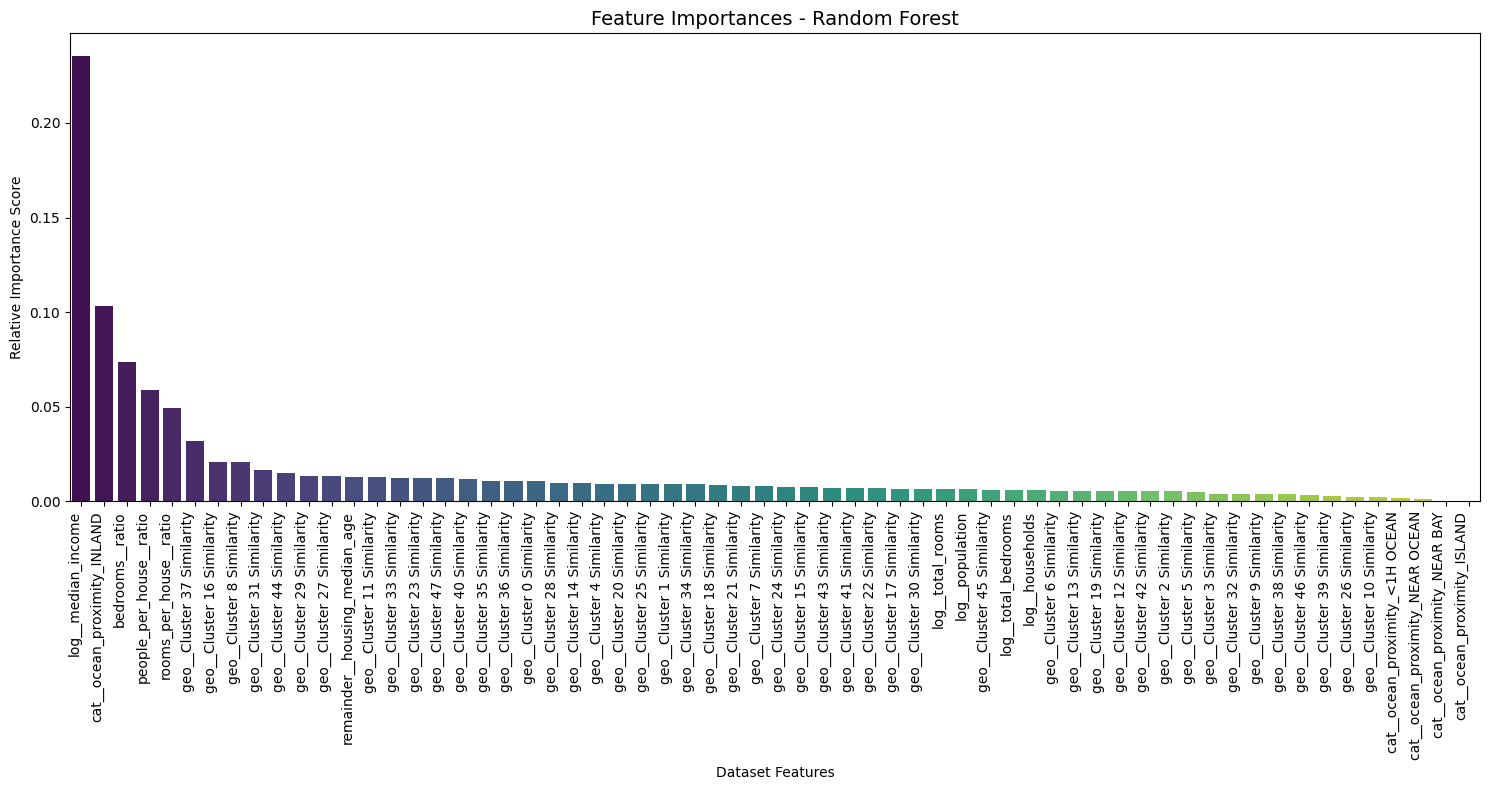

In [99]:
feature_names = best_rf["preprocessing"].get_feature_names_out()
importances = best_rf["rf"].feature_importances_
importances_df = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(15,8))
sns.barplot(x="Feature", y="Importance", data=importances_df, palette="viridis", hue="Feature", legend=False)
plt.xticks(rotation=90, ha="right", fontsize=10)
plt.title("Feature Importances - Random Forest", fontsize=14)
plt.xlabel("Dataset Features")
plt.ylabel("Relative Importance Score")
plt.tight_layout()
plt.show()

### **XGBoost Regressor** 

In [100]:
xgboost_reg.named_steps["xgbregressor"].get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 3,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [101]:
full_xg_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("xg", XGBRegressor(random_state=3, n_jobs=-1))
])

param_grid = [
    {"preprocessing__geo__n_clusters": randint(low=3, high=50),
     "xg__learning_rate": uniform(loc=0.01, scale=0.29),
     "xg__n_estimators": [100, 150, 200, 250, 300, 350, 400, 450, 500],
     "xg__max_depth": randint(low=3, high=15),
     "xg__colsample_bytree": uniform(loc=0.2, scale=0.7),
     "xg__colsample_bynode": uniform(loc=0.2, scale=0.7),
     "xg__subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
     "xg__min_child_weight": randint(low=2, high=20)
    }
]

rnd_search = RandomizedSearchCV(full_xg_pipeline, param_distributions=param_grid, n_iter=30, cv=3, 
                                scoring="neg_root_mean_squared_error", random_state=3, n_jobs=-1)

In [102]:
rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                         'xg__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e308cbacda0>,
                                         'xg__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e308c352090>,
                                         'xg__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e308c351310>,
                                         'xg__n_estimators': [100, 150, 200,
                                                              250, 300, 350,
                                                              400, 450, 500],
                                         'xg__subsample': [0.5, 0.6, 0.7, 0.8,
                                                           0.9, 1.0]}],
                   random_state=3, scoring='neg_root_mean_squared_error')

In [103]:
rnd_search.best_params_

{'preprocessing__geo__n_clusters': 42,
 'xg__colsample_bynode': np.float64(0.5120671250990712),
 'xg__colsample_bytree': np.float64(0.24798494278328576),
 'xg__learning_rate': np.float64(0.032183921871627545),
 'xg__max_depth': 10,
 'xg__min_child_weight': 2,
 'xg__n_estimators': 250,
 'xg__subsample': 1.0}

In [104]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

cv_res = cv_res[["param_preprocessing__geo__n_clusters", "param_xg__colsample_bynode", "param_xg__colsample_bytree", "param_xg__learning_rate", 
                 "param_xg__max_depth", "param_xg__min_child_weight", "param_xg__n_estimators", "param_xg__subsample",
                 "split0_test_score", "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "colsample_bynode", "colsample_bytree", "learning_rate", "max_depth", "min_child_weight", "n_estimators", 
                  "subsample"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.sample(n=10)

,n_clusters,colsample_bynode,colsample_bytree,learning_rate,max_depth,min_child_weight,n_estimators,subsample,split0,split1,split2,mean_test_rmse
18,20,0.376219,0.828416,0.252221,12,15,100,0.5,47662,47388,47527,47526
13,35,0.848708,0.787435,0.220633,14,10,300,0.5,46891,47071,47771,47244
0,45,0.249507,0.787964,0.045185,8,12,350,0.5,42679,42767,42809,42752
7,34,0.252640,0.732405,0.028493,7,19,200,0.7,44838,45246,44838,44974
5,49,0.453095,0.357538,0.127891,13,13,300,0.8,42156,43150,42788,42698
25,21,0.420257,0.395506,0.134936,13,5,350,1.0,43572,43834,43204,43536
17,34,0.251537,0.824675,0.195651,6,17,400,0.6,44294,45298,44455,44682
12,26,0.331470,0.866471,0.207667,14,9,150,0.8,44193,45810,45514,45172
9,24,0.437894,0.600956,0.104484,3,11,150,0.9,49055,49113,49354,49174
4,3,0.831984,0.792026,0.119618,11,9,350,1.0,48435,47649,47298,47794


In [105]:
best_xg_rmse = -rnd_search.best_score_
best_xg_rmse

np.float64(41909.87016644943)

In [106]:
best_xg = rnd_search.best_estimator_

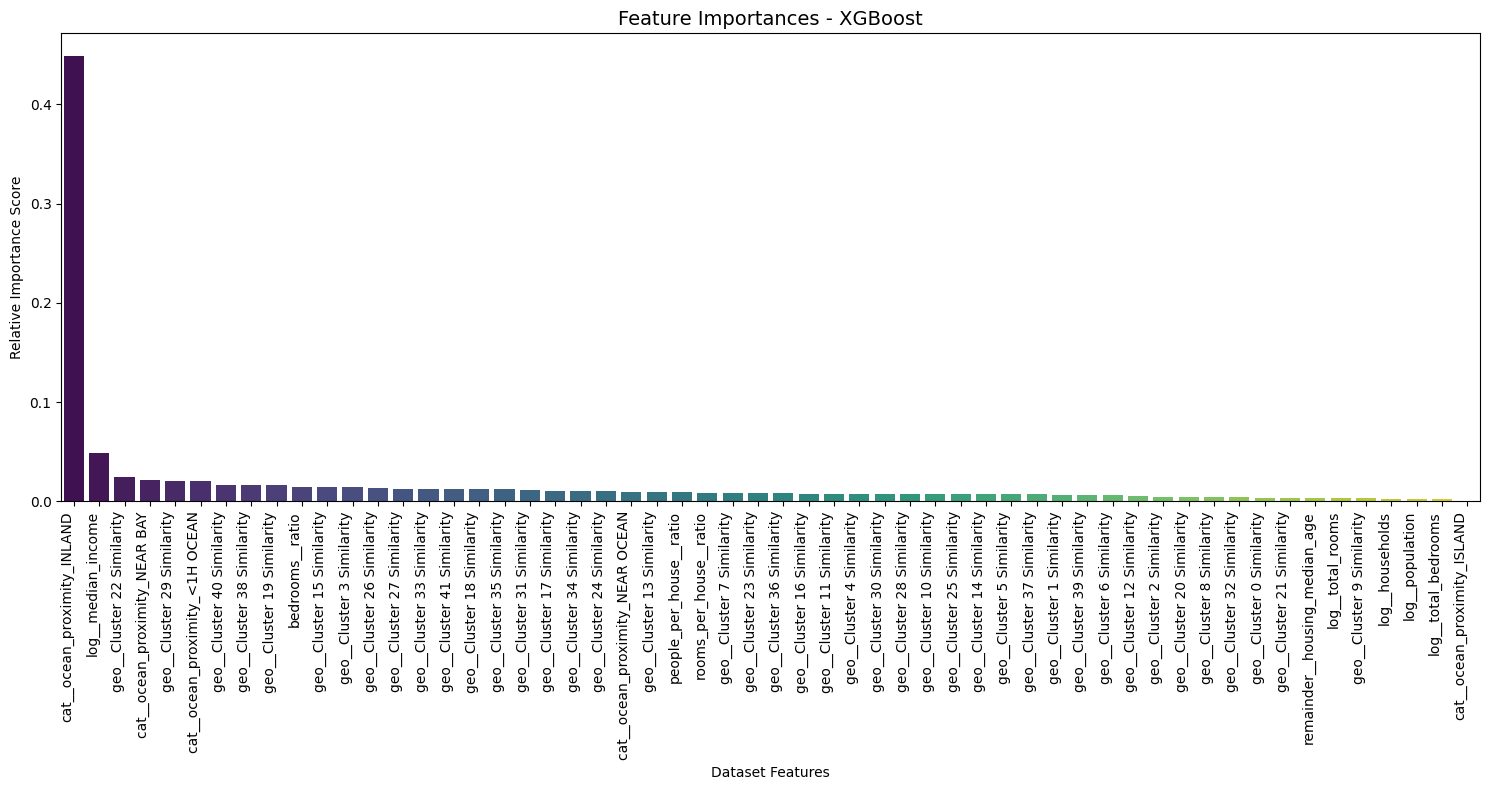

In [107]:
feature_names = best_xg["preprocessing"].get_feature_names_out()
importances = best_xg["xg"].feature_importances_
importances_df = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(15,8))
sns.barplot(x="Feature", y="Importance", data=importances_df, palette="viridis", hue="Feature", legend=False)
plt.xticks(rotation=90, ha="right", fontsize=10)
plt.title("Feature Importances - XGBoost", fontsize=14)
plt.xlabel("Dataset Features")
plt.ylabel("Relative Importance Score")
plt.tight_layout()
plt.show()

### **LightGBM Regressor**  

In [108]:
lightgbm_reg.named_steps["lgbmregressor"].get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': -1,
 'num_leaves': 31,
 'objective': None,
 'random_state': 3,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'verbose': -1}

In [109]:
full_lgbm_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("lgbm", LGBMRegressor(random_state=3, device="gpu", verbose=-1))
])

param_grid = [
    {"preprocessing__geo__n_clusters": randint(low=3, high=50),
     "lgbm__learning_rate": uniform(loc=0.01, scale=0.29),
     "lgbm__n_estimators": [100, 150, 200, 250, 300, 350, 400, 450, 500],
     "lgbm__max_depth": [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
     "lgbm__num_leaves": randint(low=20, high=100),
     "lgbm__colsample_bytree": uniform(loc=0.2, scale=0.7),
     "lgbm__subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
     "lgbm__min_child_samples": randint(low=10, high=100)
    }
]

rnd_search = RandomizedSearchCV(full_lgbm_pipeline, param_distributions=param_grid, n_iter=30, cv=3, 
                                scoring="neg_root_mean_squared_error", random_state=3, n_jobs=-1)

In [110]:
rnd_search.fit(housing, housing_labels)

1111 warning warning warning generated generated generated.
.
 warning.
 generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning gen

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                         'lgbm__n_estimators': [100, 150, 200,
                                                                250, 300, 350,
                                                                400, 450, 500],
                                         'lgbm__num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e3093de9df0>,
                                         'lgbm__subsample': [0.5, 0.6, 0.7, 0.8,
                                                             0.9, 1.0],
                                         'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e30939a7080>}],
                   random_state=3, scoring='neg_root_mean_squared_error')

In [111]:
rnd_search.best_params_

{'lgbm__colsample_bytree': np.float64(0.6103770331274749),
 'lgbm__learning_rate': np.float64(0.09221148010534083),
 'lgbm__max_depth': 10,
 'lgbm__min_child_samples': 23,
 'lgbm__n_estimators': 350,
 'lgbm__num_leaves': 50,
 'lgbm__subsample': 0.5,
 'preprocessing__geo__n_clusters': 36}

In [112]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

cv_res = cv_res[["param_lgbm__colsample_bytree", "param_lgbm__learning_rate", "param_lgbm__max_depth", "param_lgbm__min_child_samples",
                 "param_lgbm__n_estimators", "param_lgbm__num_leaves", "param_lgbm__subsample", "param_preprocessing__geo__n_clusters", 
                 "split0_test_score", "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["colsample_bytree", "learning_rate", "max_depth", "min_child_samples", "n_estimators", "num_leaves", "subsample", 
                  "n_clusters"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.sample(n=10)

,colsample_bytree,learning_rate,max_depth,min_child_samples,n_estimators,num_leaves,subsample,n_clusters,split0,split1,split2,mean_test_rmse
12,0.684034,0.198638,7,54,250,36,0.5,37,44446,44298,43992,44245
26,0.773679,0.097725,11,62,250,89,0.9,29,44055,43715,43624,43798
24,0.788994,0.220874,8,44,450,50,0.9,14,46306,45752,45433,45830
17,0.870835,0.232184,7,52,500,46,0.5,23,45283,45483,45454,45407
13,0.250793,0.067703,5,62,150,38,0.7,26,46495,46943,46718,46719
4,0.610634,0.089727,14,43,100,57,0.9,33,44141,44332,43670,44048
19,0.251537,0.268794,15,95,250,99,0.9,14,45644,46168,46240,46017
7,0.453095,0.075266,8,84,300,36,0.5,35,43654,43961,43580,43732
20,0.380044,0.090226,6,81,300,83,0.6,16,44641,44800,45326,44922
0,0.585559,0.215363,11,82,100,41,1.0,22,44879,45177,44704,44920


In [113]:
best_lgbm_rmse = -rnd_search.best_score_
best_lgbm_rmse

np.float64(43057.51435664122)

In [114]:
best_lgbm = rnd_search.best_estimator_

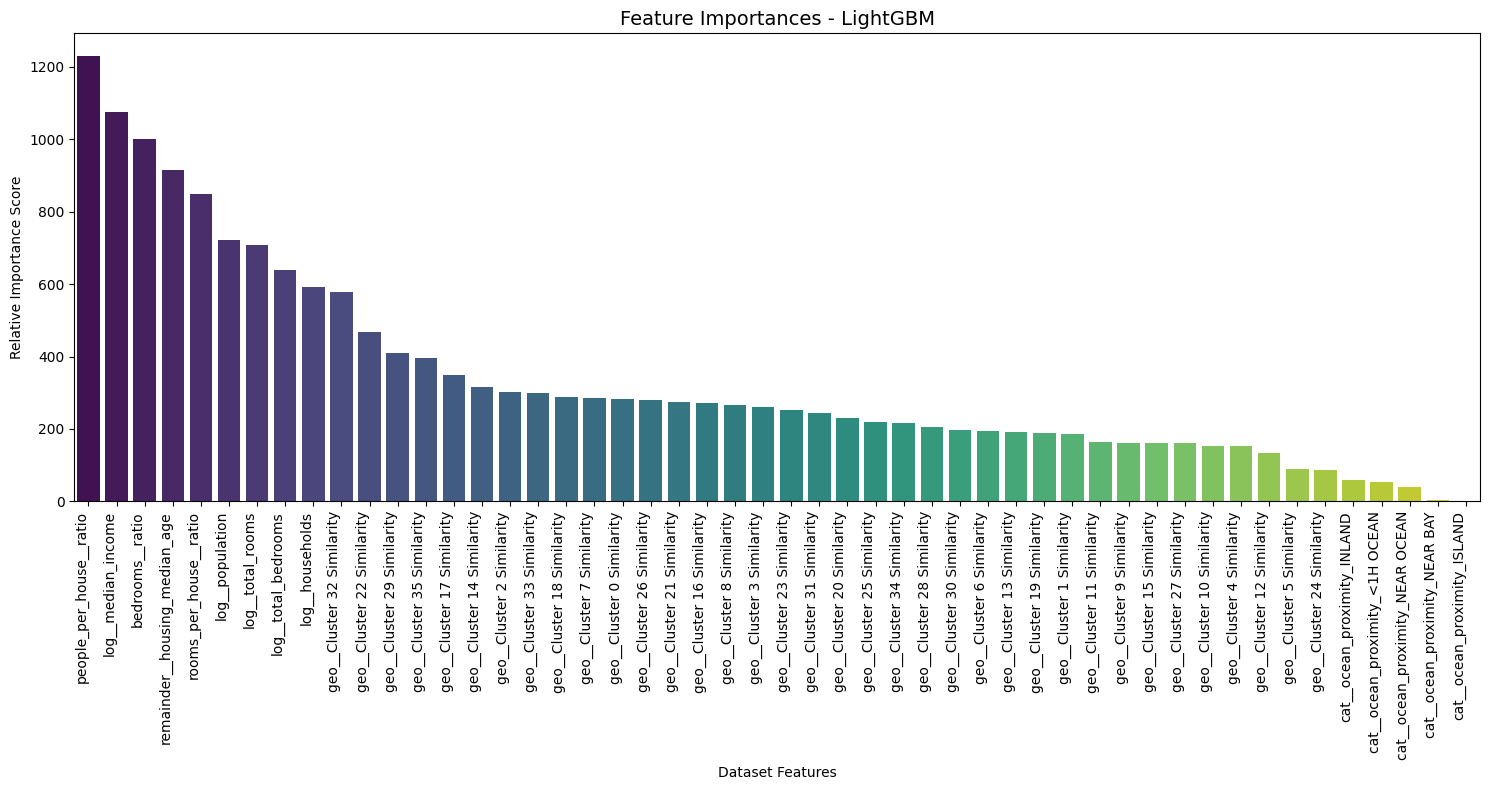

In [115]:
feature_names = best_lgbm["preprocessing"].get_feature_names_out()
importances = best_lgbm["lgbm"].feature_importances_
importances_df = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(15,8))
sns.barplot(x="Feature", y="Importance", data=importances_df, palette="viridis", hue="Feature", legend=False)
plt.xticks(rotation=90, ha="right", fontsize=10)
plt.title("Feature Importances - LightGBM", fontsize=14)
plt.xlabel("Dataset Features")
plt.ylabel("Relative Importance Score")
plt.tight_layout()
plt.show()

## **Final Model Selection & Evaluation**   

In [116]:
final_model = best_xg

In [117]:
X_test = test_set.drop("median_house_value", axis=1)
Y_test = test_set["median_house_value"].copy()

In [118]:
final_pred = final_model.predict(X_test)

In [119]:
final_rmse = root_mean_squared_error(Y_test, final_pred)
final_mae = mean_absolute_error(Y_test, final_pred)
final_r2 = r2_score(Y_test, final_pred)
final_mse = mean_squared_error(Y_test, final_pred)
print(f"Root Mean Squared Error (RMSE): ",final_rmse)
print(f"Mean Absolute Error (MAE): ",final_mae)
print(f"R2 Score: ",final_r2)
print(f"Mean Squared Error (MSE): ",final_mse)

Root Mean Squared Error (RMSE):  39959.46270985341
Mean Absolute Error (MAE):  25163.875054884327
R2 Score:  0.8792444188126489
Mean Squared Error (MSE):  1596758660.0601654


In [120]:
boot_result = bootstrap(data=(final_pred - Y_test,), statistic=lambda x, axis: np.sqrt(np.mean(x**2, axis=axis)), 
                              confidence_level=0.95, random_state=3)

print(f"95% RMSE Interval: [${boot_result.confidence_interval.low:,.2f}, ${boot_result.confidence_interval.high:,.2f}]")

95% RMSE Interval: [$37,973.60, $42,362.84]


In [121]:
joblib.dump(final_model, "california_housing_xgboost.pkl", compress=3)
print("Success!!")

Success!!
